<a href="https://colab.research.google.com/github/khuethieuttk/khuethieuttk/blob/main/Medical%20Insurance%20Cost%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project Topic**: Predicting Medical Insurance Costs Using Multiple Linear Regression


# **Problem Statements**


1.   How can we mathematically model the relationship between personal characteristics (age, sex, BMI, children, smoker, region) and medical charges?

2. Which specific factors serve as the strongest predictors of high medical expenses?

3. How can we optimize a predictive model to account for the skewed nature of medical cost data and ensure statistical validity?




#**Import Library**

In [ ]:
import pandas as pd #data manipulation
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import kagglehub
import os
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf

# Set visual style
sns.set(style="whitegrid")

# **1. Download the dataset**

In [ ]:
# Download latest version
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

import pandas as pd

file_path = os.path.join(path, "insurance.csv")
df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


# **2. Exploratory Data Analysis (EDA)**

# **Understand the variables**

**`age`**: age of primary beneficiary

**`sex`**: insurance contractor gender, female, male

**`bmi`**: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight ($kg / m ^ 2$) using the ratio of height to weight, ideally 18.5 to 24.9

**`children`**: Number of children covered by health insurance / Number of dependents

**`smoker`**: Smoking

**`region`**: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

**`charges`**: Individual medical costs billed by health insurance **(target)**

#**2.1 Dataset Overview & Data cleaning**

***See the shape of dataset***

In [ ]:
df.shape

(1338, 7)

The dataset has 1338 rows and 7 columns

In [ ]:
# Show the first few rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Observation**

* `age`, `bmi`, `children` are the numerical values
* `sex`, `smoker`, `region` are the categorical values
* `charges` is the target value

***See summary statistics***

In [ ]:
# Summary Statistics for numerical data
print(df[['age','bmi','children','charges']].describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


**Data Overview:**

- The dataset consists of 1,338 rows and 7 columns, with no missing values.

- Age Range: 18 to 64 years old (average 39 years old).

- BMI: Average 30.66 (overweight/obese).

- Number of Children: Average approximately 1 child, maximum 5.

- Charges: Average 13,270, lowest 1,121 and highest 63,770.

In [ ]:
# Show the variance and standard deviation
var_charges = np.round(np.var(df['charges']),2)
std_charges = np.round(np.std(df['charges']),2)
print('Variance of charges: ', var_charges)
print('Standard Deviation of charges: ', std_charges)

Variance of charges:  146542766.49
Standard Deviation of charges:  12105.48


***Check null values***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The dataset has no null values

***Check dupplicates***

In [ ]:
duplicates = df[df.duplicated()]
duplicates


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


The dataset has 1 duplucated row.

In [ ]:
df = df.drop_duplicates()

Drop the duplicate.

***Normalize the data***

In [ ]:
df["sex"].unique()

array(['female', 'male'], dtype=object)

Change the values of `sex` columns to:

 **1 for 'female'**

 **0 for 'male'**


In [ ]:
df['sex'] = df['sex'].replace({'female': 1, 'male': 0})
df['sex']

/tmp/ipython-input-350913637.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'female': 1, 'male': 0})


,sex
0,1
1,0
2,0
3,0
4,0
...,...
1333,0
1334,1
1335,1
1336,1


In [ ]:
df['smoker'] = df['smoker'].replace({'yes': 1, 'no': 0})
df['smoker']

/tmp/ipython-input-1608388076.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoker'] = df['smoker'].replace({'yes': 1, 'no': 0})


,smoker
0,1
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


Change the values of `smoker` columns to:

 **1 for 'yes'**

 **0 for 'no'**


In [ ]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
#dummy variable
df_encoded = pd.get_dummies(df, columns=['region'], drop_first=True)

#**2.2 Urivariate Analysis**

## **2.2.1 Histogram: Distribution of variables**

Purpose: To understand each variable’s distribution, shape, skewness, and spread

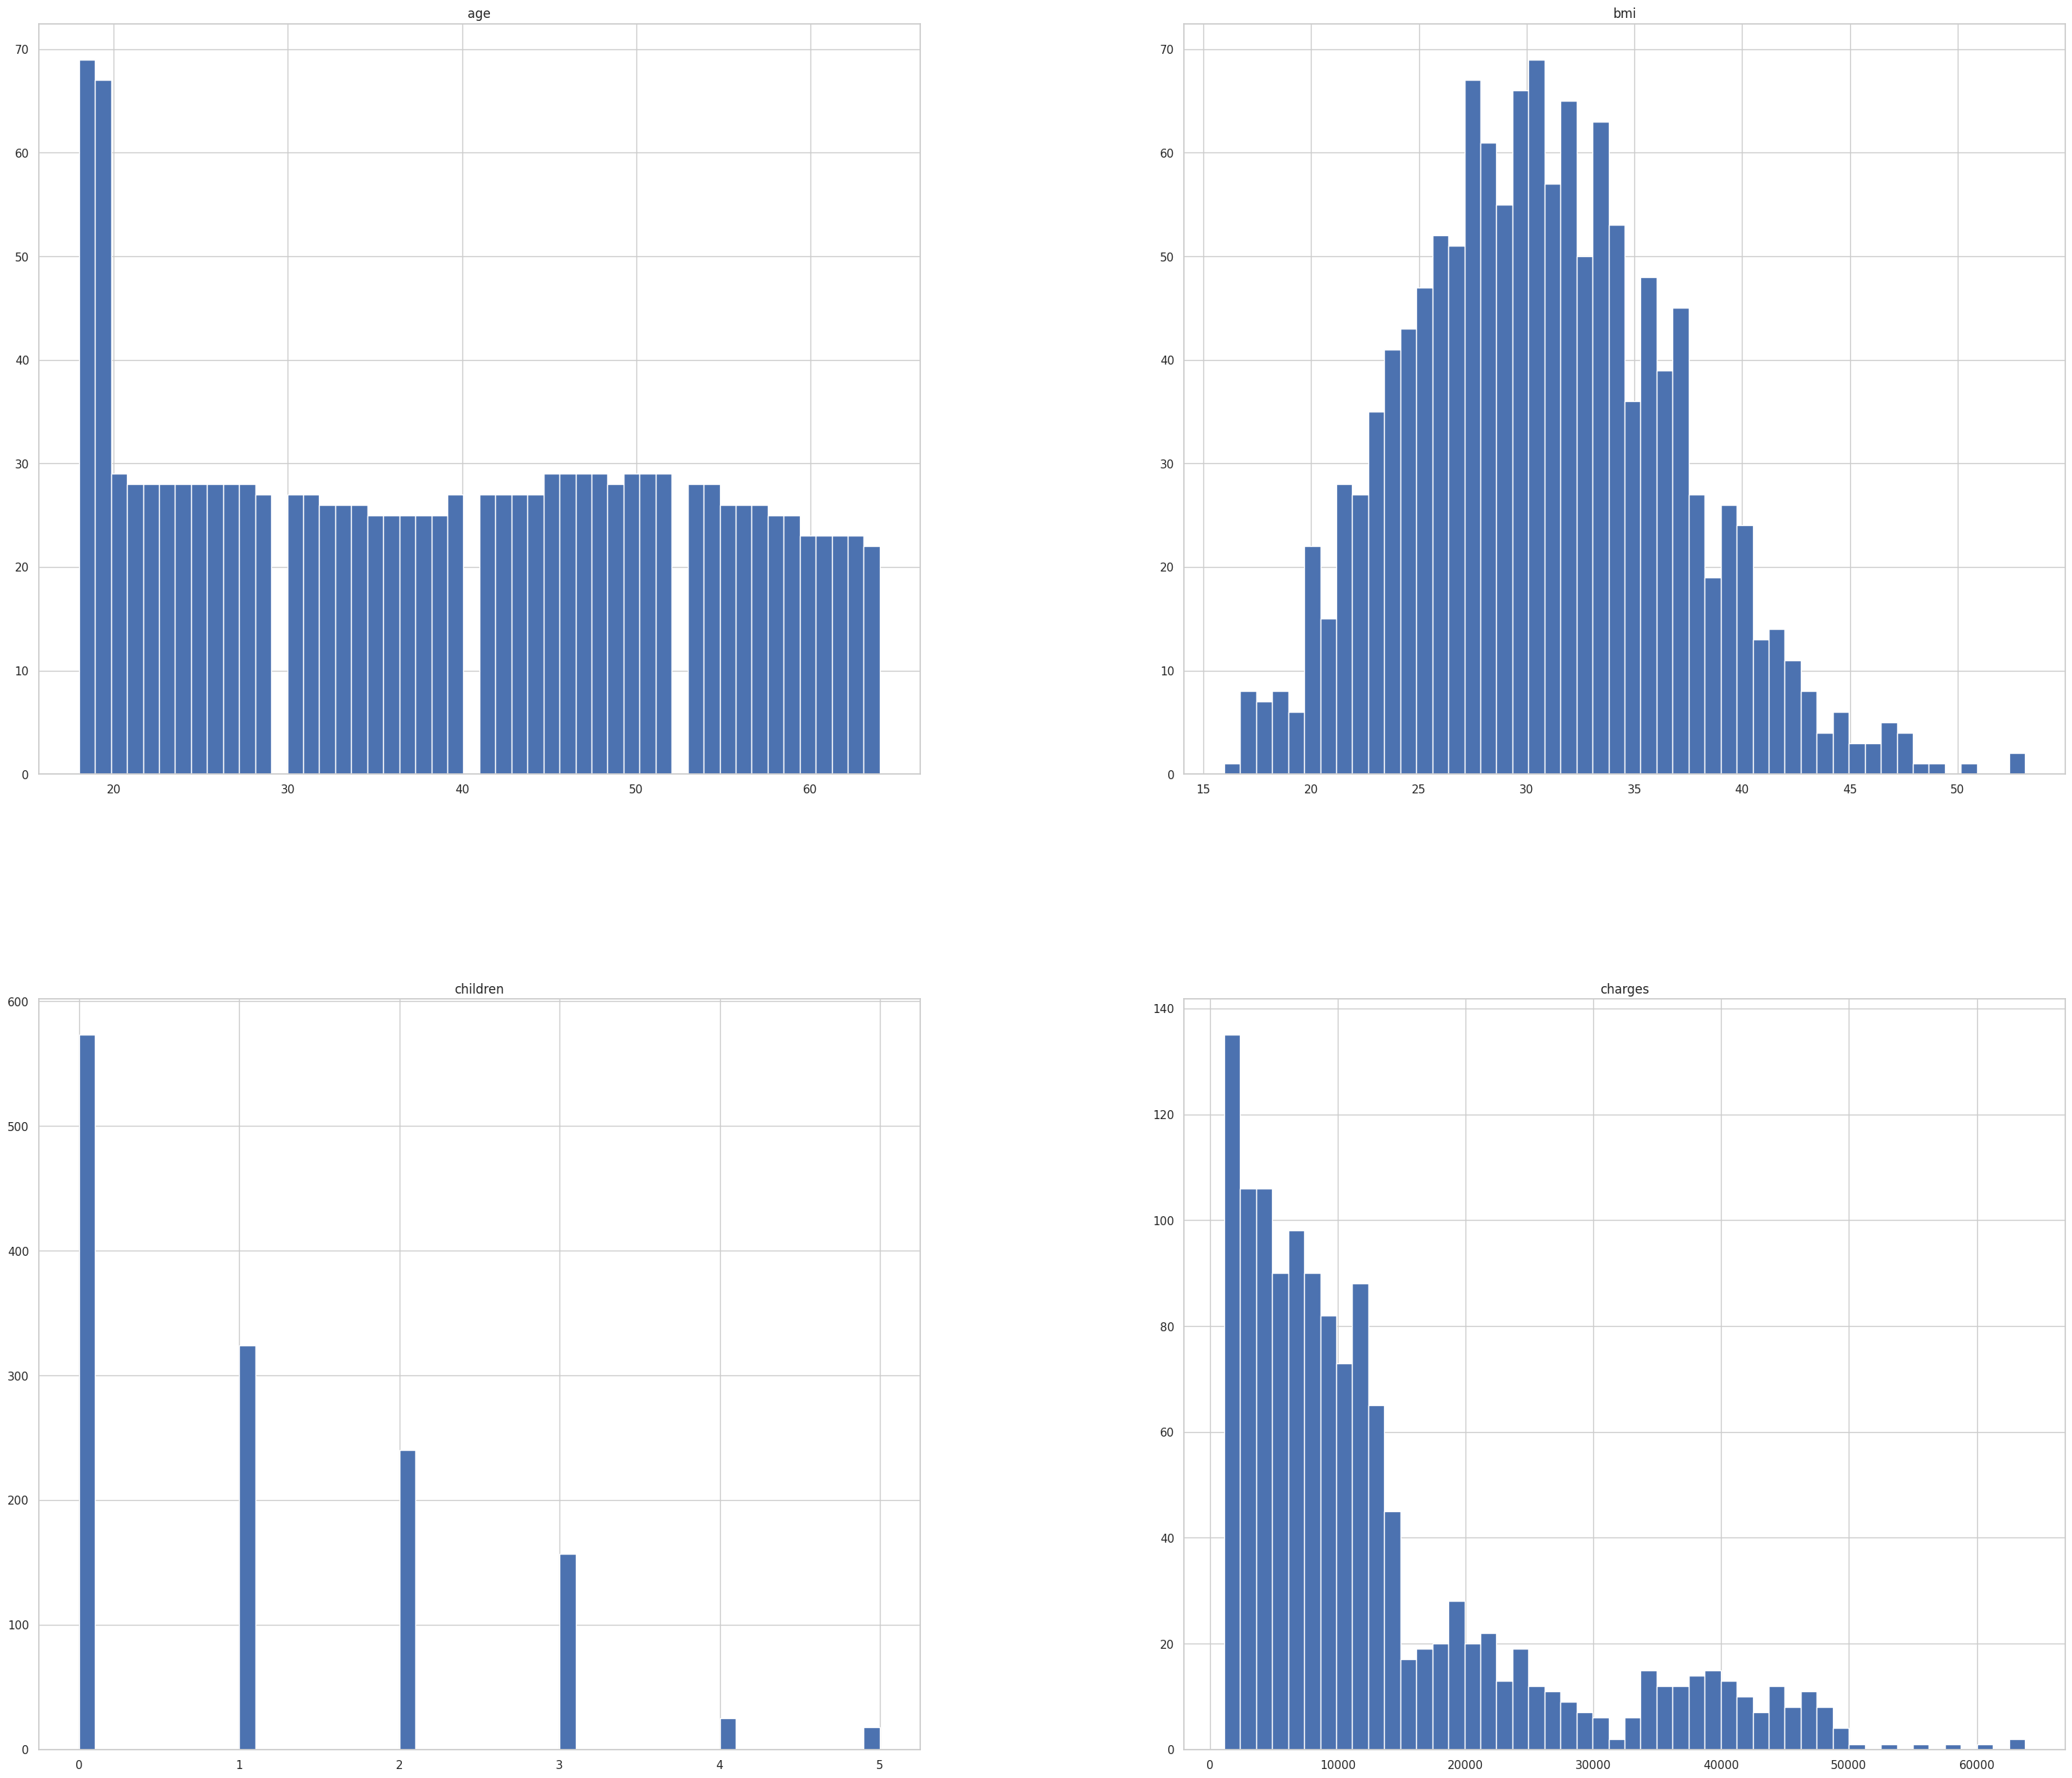

In [ ]:
#Distribution of variables
df[['age','bmi','children','charges']].hist(figsize = (35,30), bins = 50)
plt.show()

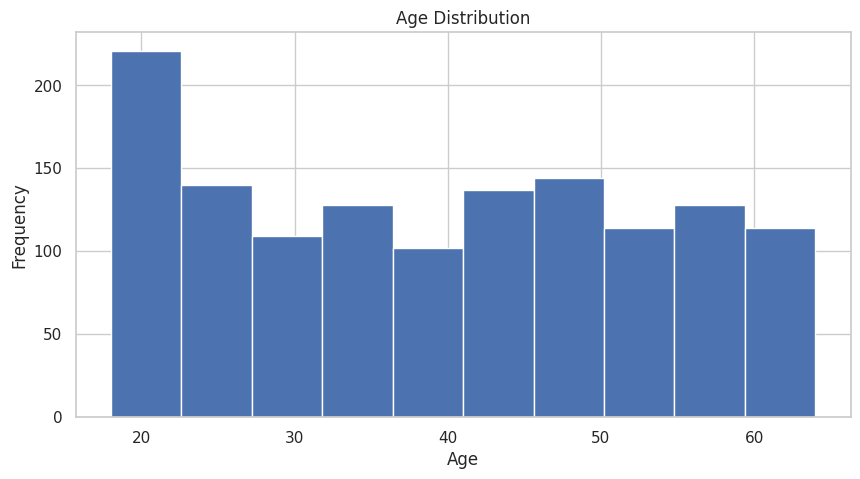

In [ ]:
plt.figure(figsize=(10, 5))
df['age'].hist(bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('age_hist.png')
plt.show()

* `charges` column is right-skewed.

* `bmi` is close to be normal distributed.

* for `age`, there is a spike in the 20s, applying that the beneficiary in this age groups have the biggest density.

* People tend to have from 0-2 children in `children`, 3-5 only accounts for a small portion.



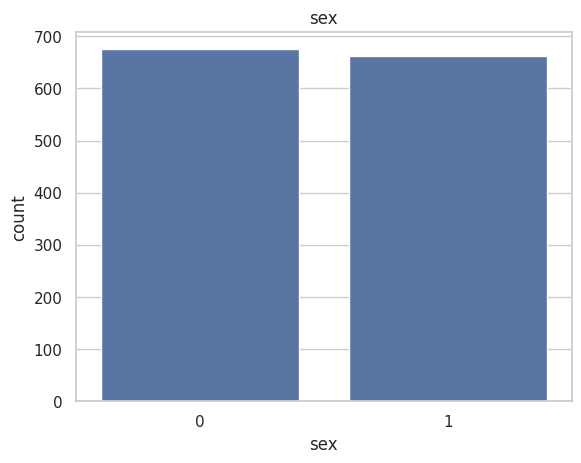

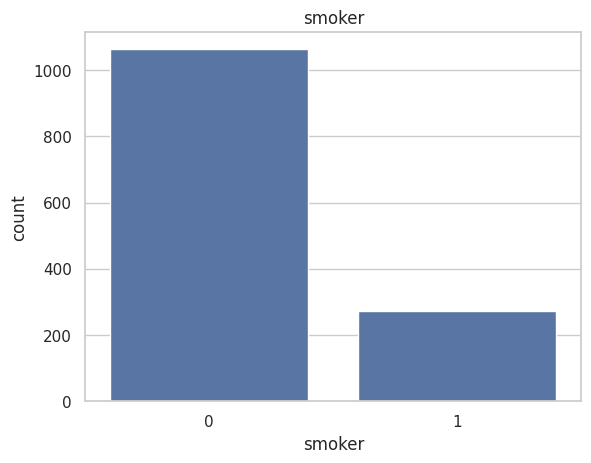

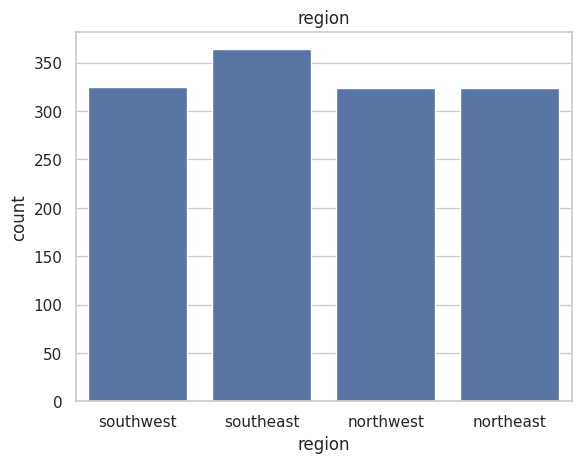

In [ ]:
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()


* `sex` and `region` are distributed equally.
* People who don't smoke outnumbers people who do in `smoker`.

[]

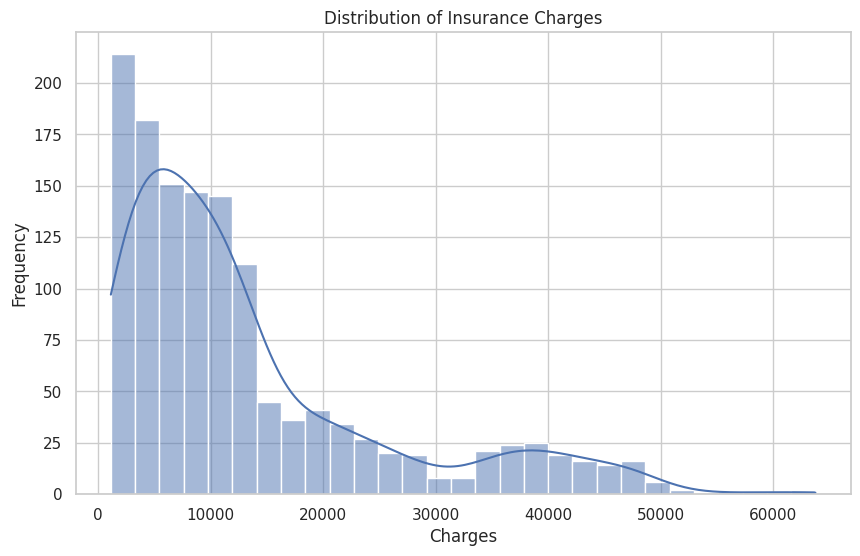

In [ ]:
# Distribution of Charges
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, color="#4C72B0")
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.savefig('charges_distribution.png')
plt.plot()

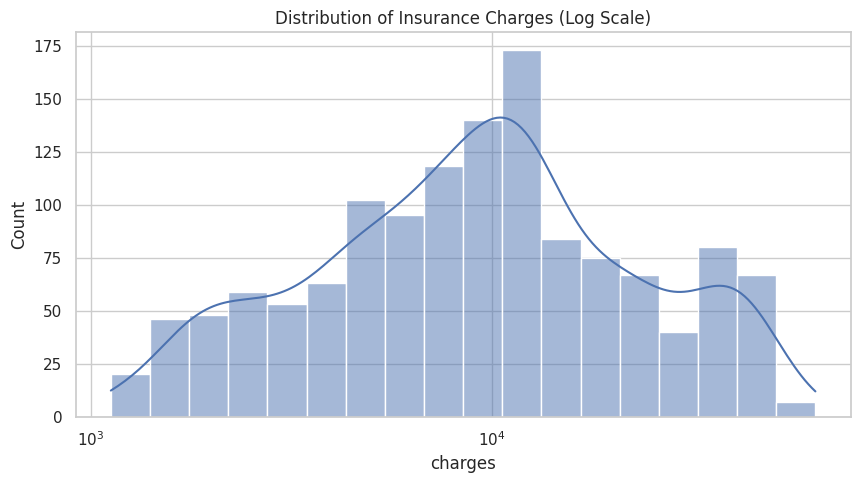

In [ ]:
# Distribution of Charges (log scale)
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color="#4C72B0", log_scale=True)
plt.title('Distribution of Insurance Charges (Log Scale)')
plt.show()

If we look at the distribution plot, the charges varies from 1120 to 63500, the plot is right skewed. In the distribution log scale plot we will apply natural log, then plot approximately tends to normal. for further analysis we will apply log on target

##**2.2.2 Boxplot:** to determine the spread, quantiles and detect outliers

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols]

def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (series < lower) | (series > upper)


outlier_summary = {}

for col in num_cols:
    mask = iqr_outliers(df[col])
    outlier_summary[col] = mask.sum()

outlier_df = pd.DataFrame({
    'Variable': outlier_summary.keys(),
    '# Outliers': outlier_summary.values()
}).sort_values('# Outliers', ascending=False)

#Identify the top variables having the most outliers
outlier_df

,Variable,# Outliers
4,smoker,274
5,charges,139
2,bmi,9
0,age,0
1,sex,0
3,children,0


Besides the `region`, which is a categorical value (its outliers have no statiscal meaning), `charges` is the variable with the most outliers (139). Hence we need to look deeper at this using the boxplot.

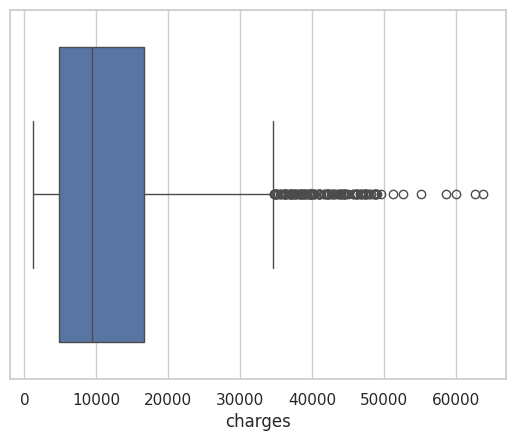

In [ ]:
sns.boxplot(data=df,x='charges')
plt.show()

#**2.3 Bivariate Analysis**

##**2.3.1 Bar chart distribution:** to show for each group of age, BMI, and children, who pays the most for insurance

/tmp/ipython-input-1083446733.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups_charges = df.groupby('age_group')['charges'].mean().reset_index()


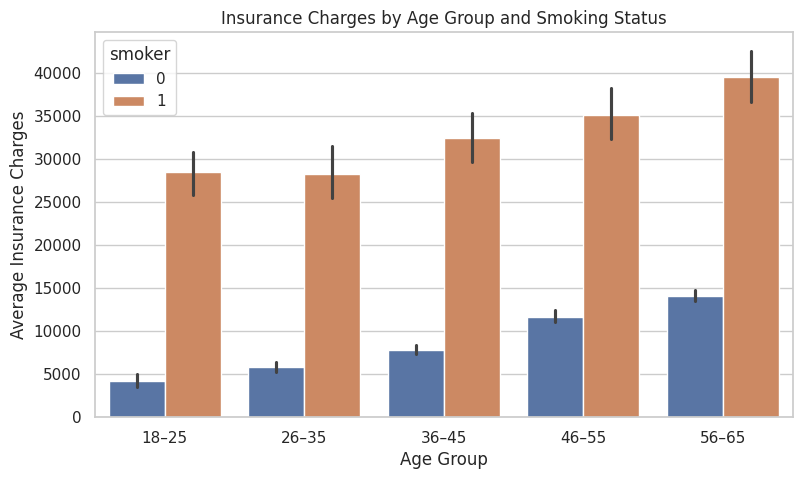

In [ ]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_groups_charges = df.groupby('age_group')['charges'].mean().reset_index()

plt.figure(figsize=(9,5))
sns.barplot(
    x='age_group',
    y='charges',
    hue='smoker',
    data=df
)

plt.xlabel('Age Group')
plt.ylabel('Average Insurance Charges')
plt.title('Insurance Charges by Age Group and Smoking Status')
plt.show()


/tmp/ipython-input-4156661656.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_groups_charges = df.groupby('bmi_group')['charges'].mean().reset_index()


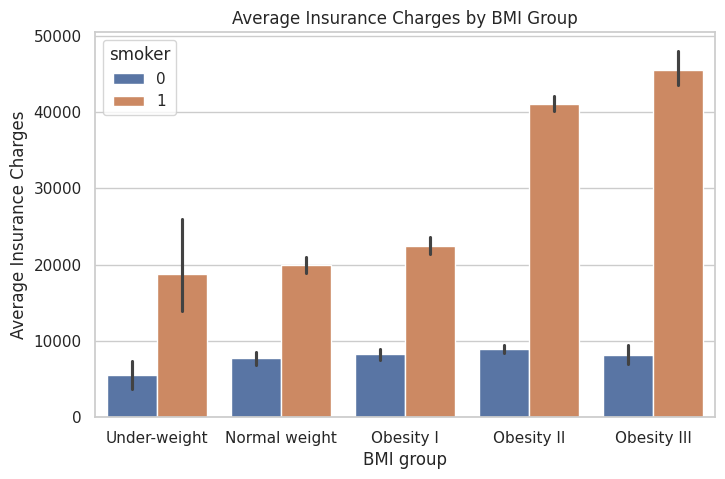

In [ ]:
#Avg charges by BMI group

bins = [15, 18.5, 25, 30, 40, 55]
labels = ['Under-weight', 'Normal weight', 'Obesity I', 'Obesity II', 'Obesity III']

df['bmi_group'] = pd.cut(df['bmi'], bins=bins, labels=labels)

bmi_groups_charges = df.groupby('bmi_group')['charges'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    x='bmi_group',
    y='charges',
    hue='smoker',
    data=df
)

plt.xlabel('BMI group')
plt.ylabel('Average Insurance Charges')
plt.title('Average Insurance Charges by BMI Group')
plt.show()


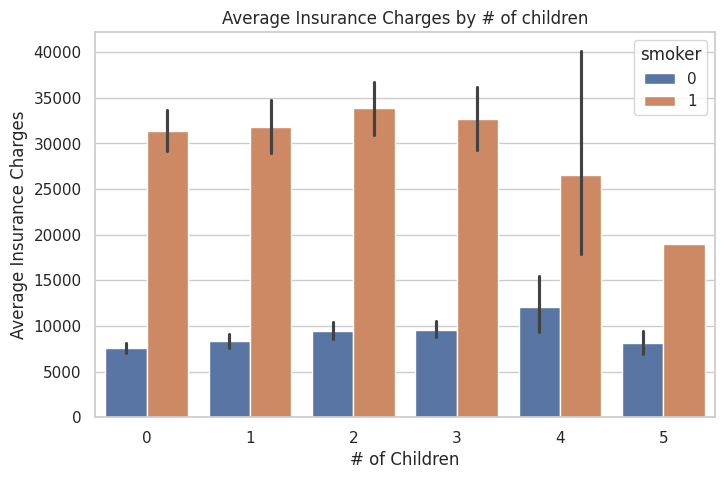

In [ ]:
#Avg charges by # of children

children_charges = df.groupby('children')['charges'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    x='children',
    y='charges',
    hue='smoker',
    data=df
)

plt.xlabel('# of Children')
plt.ylabel('Average Insurance Charges')
plt.title('Average Insurance Charges by # of children')
plt.show()


In [ ]:
print("People with less than 3 children account for",np.round(np.sum(df[df['children'] < 3]['children'].value_counts()) / len(df) *100,2),"% of the dataset")

People with less than 3 children account for 85.04 % of the dataset


**Observation:**

* `smoker` is a big factor affecting the charges on insurance.Beneficiaries that smoke are being charged higher than people who don't across variables (`age`, `bmi`, `children`).

* For `age`: It shows that the medical cost is higher as the age increases. For non-smoker group, the cost varies from 5000 to nearly 15000. And for smoker group, it varies from above 25000 to nearly 40000 on average.

* For `bmi`: It also shows that the medical cost is higher as the BMI rises. For smoker group, the Obesity II and Obesity III groups are being charged significantly higher than other groups (above 40000 on average). However, for non-smokers, the average charges is not different across BMI group.

* For `children`: Since the % of people with < 3 children is 85% of the dataset, it's understandable that the medical cost would be higher for these groups. Hence, the differences across the number of children are not noticable.

## **2.3.2 Scatter plots and box plots:** to show correlations between variables with 'charges'

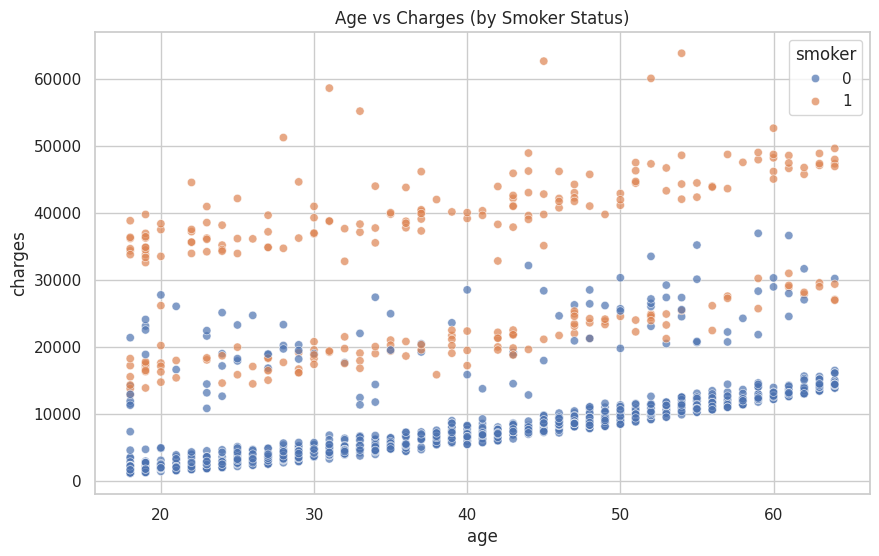

In [ ]:
# Age vs Charges colored by Smoker
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title('Age vs Charges (by Smoker Status)')
plt.savefig('age_vs_charges.png')
plt.show()

[]

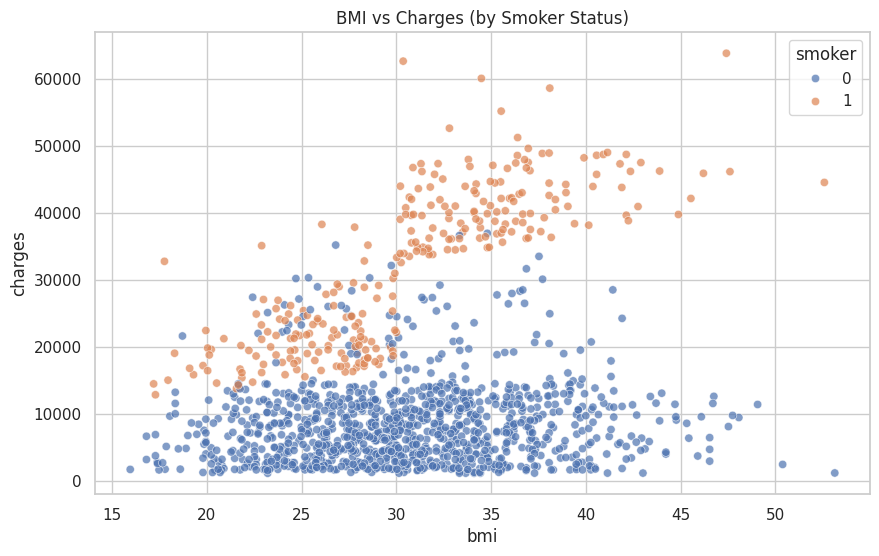

In [ ]:
# BMI vs Charges colored by Smoker
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title('BMI vs Charges (by Smoker Status)')
plt.savefig('bmi_vs_charges.png')
plt.plot()

[]

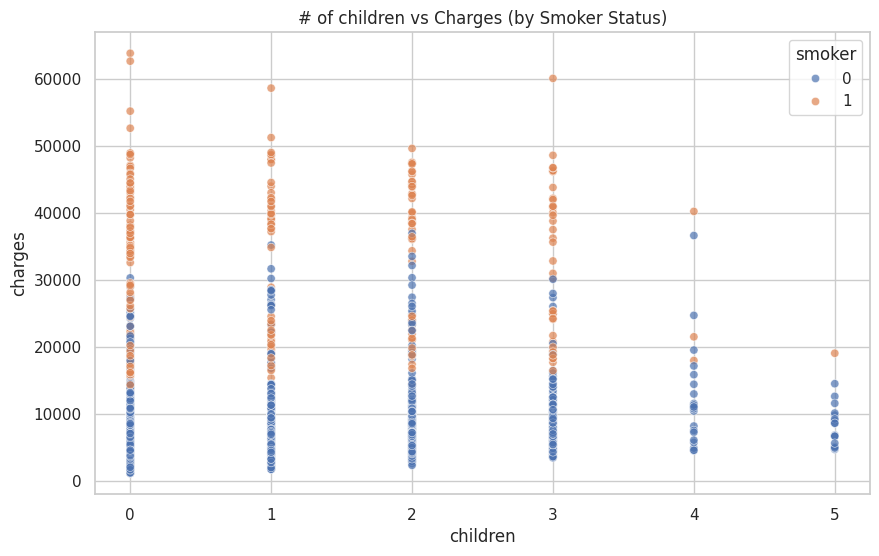

In [ ]:
# Children vs Charges colored by Smoker
plt.figure(figsize=(10, 6))
sns.scatterplot(x='children', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title('# of children vs Charges (by Smoker Status)')
plt.savefig('child_vs_charges.png')
plt.plot()

[]

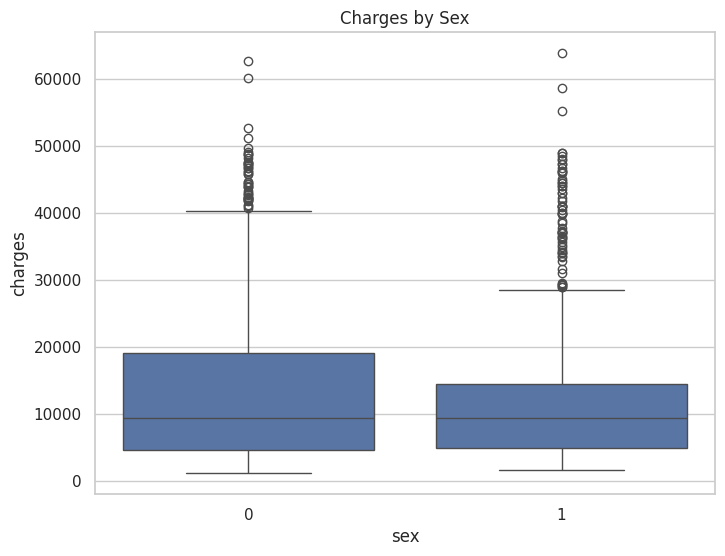

In [ ]:
#Charges by Sex
plt.figure(figsize=(8, 6))
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Charges by Sex')
plt.savefig('charges_by_sex.png')
plt.plot()

[]

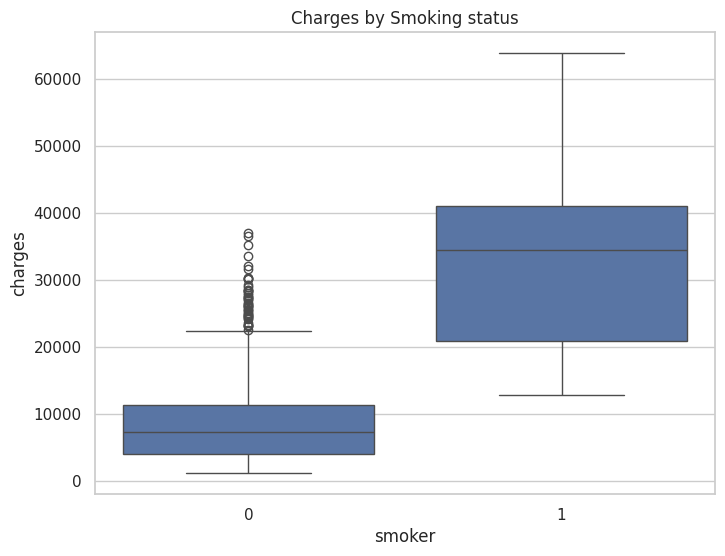

In [ ]:
#Charges by Smoke
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking status')
plt.savefig('charges_by_smoke.png')
plt.plot()

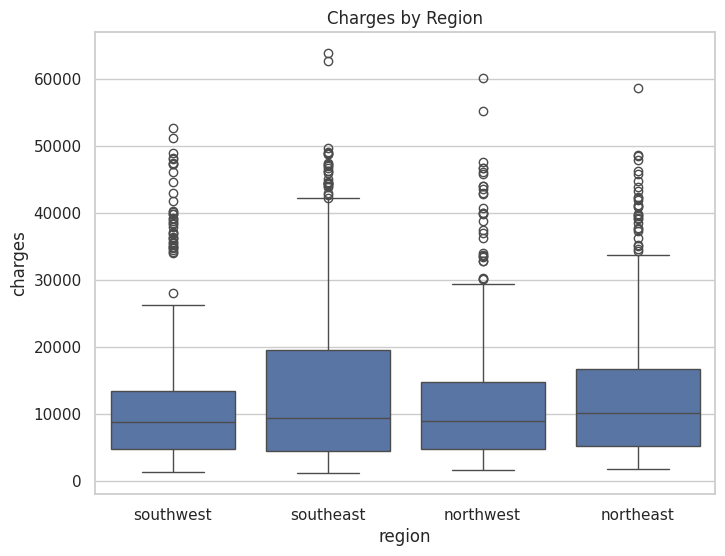

In [ ]:
#Charges by Region
plt.figure(figsize=(8, 6))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.savefig('charges_by_region.png')


**Observation**:

- Smoking (`smoker`) is the primary determinant of costs: There is a stark contrast in medical charges between smokers and non-smokers. While the majority of non-smokers incur costs below 15,000, smokers typically face significantly higher charges ranging from 15,000 to over 60,000.

- Correlation between `age` and `charges`: Medical charges exhibit a consistent upward trend as age increases for both smokers and non-smokers, reflecting higher health risks in older populations.

- Interaction between `bmi` and `smoker`:

   + In the smoker group, individuals with a BMI > 30 (classified as obese) incur exceptionally high costs, often exceeding $30,000. Smokers with a BMI < 30 face relatively lower charges.

   + For non-smokers, the impact of BMI on medical charges is much less pronounced compared to the smoking group.

- Correlation between `children`, `age`, `region` with `charges`: It shows a non linear relationship between these 3 variables with the medical cost.


##**2.3.3 Correlation between variables**

Purpose: To assess multicollinearity and variable redundancy.

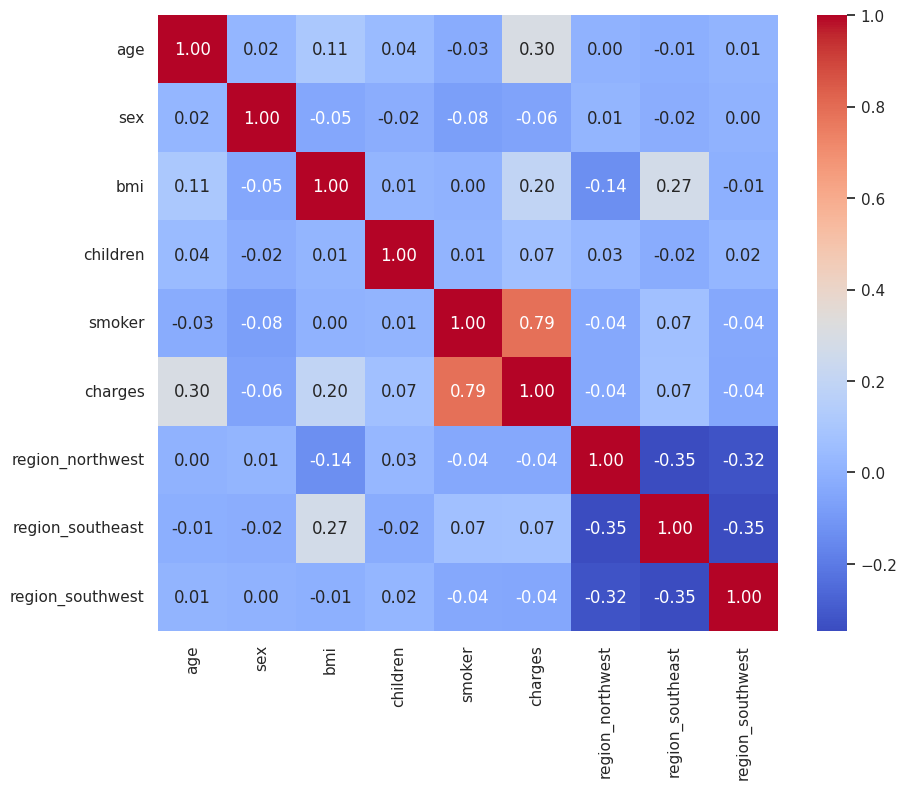

In [ ]:
# Calculate correlation
corr = df_encoded.corr()
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f");
plt.savefig('correlation_map')

* `age`，`smoker`, `bmi`, and `children` are most correlated with `charges`
* `region`, and `sex` show nearly no correlation with `charges`

# **3. Linear Regression Model**

# BASELINE MODEL:

$$y = \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \beta_4 x_4 + \beta_5 x_5 + \beta_6 x_6+ \beta_0$$


$$\text{charges} = \beta_1(\text{smoker}) + \beta_2(\text{children}) + \beta_3(\text{bmi}) + \beta_4(\text{age}) + \beta_5(\text{sex})+ \beta_6 D_{NW}+ \beta_7 D_{SE} + \beta_8 D_{SW}+ \beta_0$$



In [ ]:
# X, y
X = df[['age', 'bmi', 'children', 'smoker', 'region', 'sex']]
y = df['charges']

X = pd.get_dummies(X, drop_first=True)

# Split dataset into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_raw = LinearRegression()
model_raw.fit(X_train, y_train)

# Predict
y_pred_raw = model_raw.predict(X_test)

formula_baseline = "charges ~ age + bmi + smoker + children + sex + region"

model_baseline = sm.formula.ols(
    formula=formula_baseline,
    data=df
)

model_baseline_fitted = model_baseline.fit()

print(model_baseline_fitted.summary())
print("\n--- Danh sách P-values chi tiết ---")
print(model_baseline_fitted.pvalues)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:51:49   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.207e+04   1

##Model Fit Assessment
R-squared (0.751): The model explains 75.1% of the variance in insurance charges based on four key factors: age, BMI, number of children, and smoking status.

Prob (F-statistic) (0.00): This value is approximately zero, confirming that
the model is statistically significant. Combining these four variables to predict costs is scientifically grounded and not due to random chance.

## Statistical Significance (P-value)
After removing the non-significant variables (sex and region), the model has become extremely robust

All variables (age, bmi, children, smoker): All features have a P-value = 0.000 (well below the standard 0.05 threshold).

Conclusion: All four factors have a real and statistically significant impact on medical costs. Focusing on these specific variables makes the model lean and easy to explain while maintaining high accuracy.


##Factors Affecting Insurance Charges (Interpretation of Coefficients)

$$\text{charges} = 23810\times\text{smoker} +  472.9751\times\text{children} +  321.87\times\text{bmi} +  257.7728\times\text{age} -12100$$


- Smoker (+23,810):
This is the most influential variable. If a customer is a smoker, the insurance premium increases immediately by more than USD 23,810 compared to a non-smoker with the same age and physical condition.

- Children (+472.98):
Each additional child covered by the insurance policy increases the premium by approximately USD 473.

- Age (+249.19):
For every one-year increase in age, the insurance cost rises by an average of USD 249. This reflects the increasing health risk associated with aging.

- BMI (+321.87):
For each one-unit increase in BMI, the insurance charge increases by approximately USD 321.87. This suggests an incentive for policyholders to maintain a healthy body weight.

- Intercept (−12,100):
The intercept represents a baseline value from a mathematical perspective. In practice, this negative value is not a concern because realistic values of age and BMI are sufficiently large to yield positive predicted insurance charges.


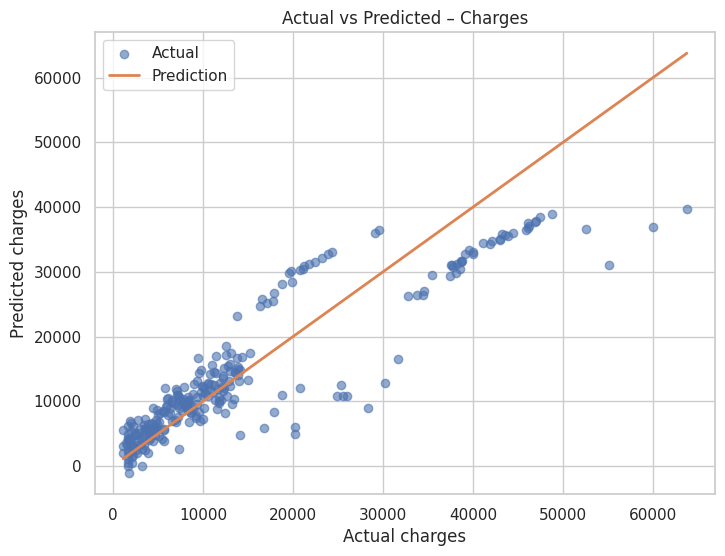

In [ ]:
# Plot results
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_raw, alpha=0.6, color="#4C72B0", label='Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="#DD8452", lw=2, label='Prediction')
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("Actual vs Predicted – Charges")
plt.legend()
plt.savefig('actual_vs_predicted_stats.png')
plt.show()

# LOG TRANSFORM MODEL:

$$log(y) = \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \beta_4 x_4 + \beta_5 x_5 + \beta_6 x_6+ \beta_0$$


$$\text{log(charges)} = \beta_1(\text{smoker}) + \beta_2(\text{children}) + \beta_3(\text{bmi}) + \beta_4(\text{age}) + \beta_5(\text{sex})+ \beta_6 D_{NW}+ \beta_7 D_{SE} + \beta_8 D_{SW}+ \beta_0$$



In [ ]:
X = df[['age', 'bmi', 'children', 'smoker', 'sex', 'region']]
X = pd.get_dummies(X, drop_first=True)
# Log transform target
y_log = np.log(df['charges'])

# Split dataset into train (80%) and test (20%)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

# Predict
y_pred_log = model_log.predict(X_test)

formula_log = "np.log(charges) ~ age + bmi + smoker + children + sex + region  "

model_log = sm.formula.ols(
    formula=formula_log,
    data=df
)

model_log_fitted = model_log.fit()

print(model_log_fitted.summary())




                            OLS Regression Results                            
Dep. Variable:        np.log(charges)   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     548.4
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:51:50   Log-Likelihood:                -807.62
No. Observations:                1337   AIC:                             1633.
Df Residuals:                    1328   BIC:                             1680.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.9569    

##Model Fit Assessment
R-squared (0.768): The model explains 76.8% of the variance in insurance charges based on six key factors: age, BMI, number of children, smoking status, sex and region

Prob (F-statistic) (0.00): This value is approximately zero, confirming that
the model is statistically significant. Combining these six variables to predict costs is scientifically grounded and not due to random chance.

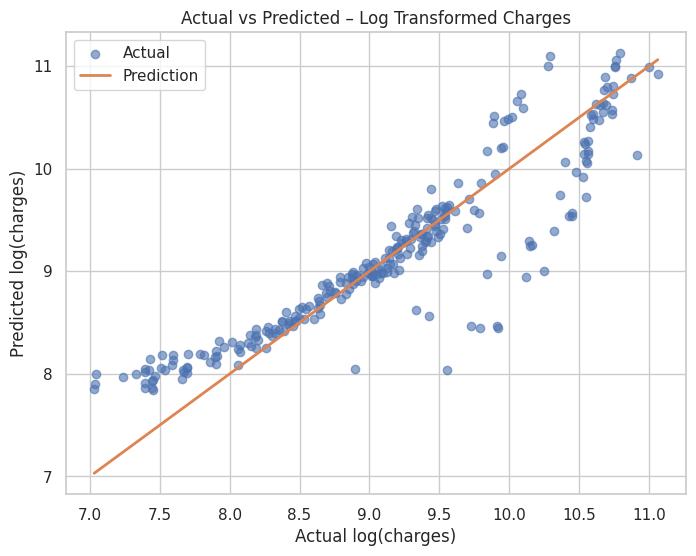

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_log, y_pred_log, alpha=0.6, color="#4C72B0", label='Actual')
plt.plot([y_test_log.min(), y_test_log.max()],
    [y_test_log.min(), y_test_log.max()], color="#DD8452", lw=2, label='Prediction')
plt.xlabel("Actual log(charges)")
plt.ylabel("Predicted log(charges)")
plt.title("Actual vs Predicted – Log Transformed Charges")
plt.legend()
plt.savefig('actual_vs_predicted_log_stats.png')
plt.show()


##Factors Affecting Insurance Charges (Interpretation of Coefficients)

$$\text{log(charges)} = 1.5538\times\text{smoker} +  0.1015\times\text{children} +  0.0134\times\text{bmi} +  0.0345\times\text{age} + 0.0746\times\text{sex}-0.062\times D_{NW} - 0.1573\times D_{SE}- 0.129\times D_{SW} +6.9569$$


- Smoker (+1.5538):
This is the most influential variable. If a customer is a smoker, the insurance premium is about $e^{1.5538} ≈4.73$ times higher  compared to a non-smoker with the same age and physical condition.

- Children (+0.1015):
Each additional child covered by the insurance policy increases the premium about 1.11 times

- Age (+0.0345):
For every one-year increase in age, the insurance cost rises by about 1.04 times. This reflects the increasing health risk associated with aging.

- BMI (+0.0134):
For each one-unit increase in BMI, the insurance charge increases by about 1.01 times. This suggests an incentive for policyholders to maintain a healthy body weight.

- Sex (+0.0746):

- Region

- Intercept (+6.9569):

In [ ]:
anova_model = smf.ols('y ~ C(region)', data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(region),1.281906e+09,3.0,2.92614,0.032763
Residual,1.946569e+11,1333.0,NaN,NaN


## **Residual Analysis: kiểm tra sai số error $y−\hat{y}$**

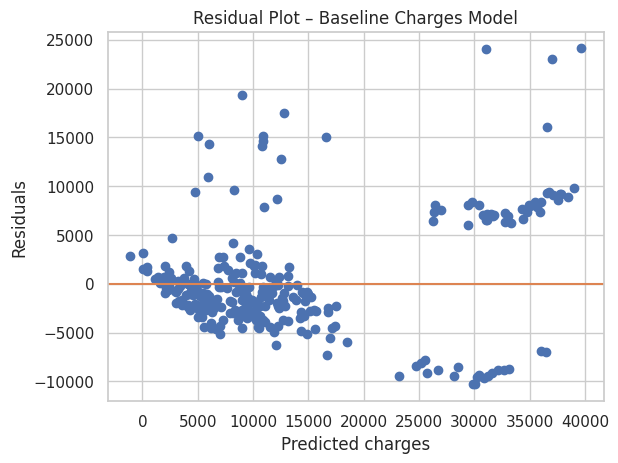

In [ ]:
residuals_raw = y_test - y_pred_raw

plt.figure()
plt.scatter(y_pred_raw, residuals_raw, color="#4C72B0")
plt.axhline(0, color="#DD8452")
plt.xlabel("Predicted charges")
plt.ylabel("Residuals")
plt.title("Residual Plot – Baseline Charges Model")
plt.savefig("residuals.png", dpi=300, bbox_inches="tight")
plt.show()

Đối với baseline_model: người có chi phí thấp thì dự đoán tốt nhưng người có chi phí cao thì dự đoán lệch rất nhiều -> heteroskedasticity



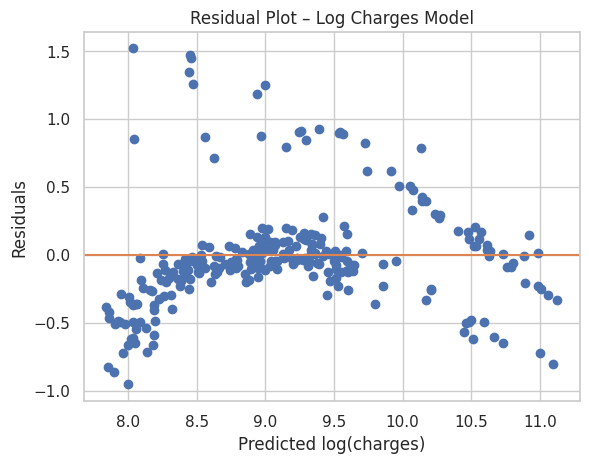

In [ ]:
residuals_log = y_test_log - y_pred_log

plt.figure()
plt.scatter(y_pred_log, residuals_log, color="#4C72B0")
plt.axhline(0, color="#DD8452")
plt.xlabel("Predicted log(charges)")
plt.ylabel("Residuals")
plt.title("Residual Plot – Log Charges Model")
plt.savefig("residuals_log.png", dpi=300, bbox_inches="tight")
plt.show()

Đối với log_model: giúp ổn định phương sai và làm mô hình đáng tin cậy hơn

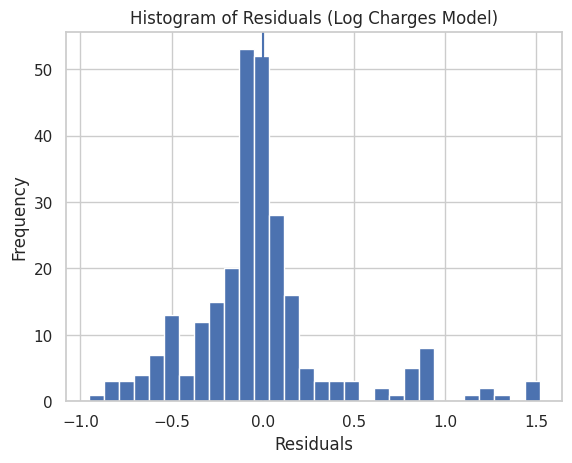

In [ ]:
plt.figure()
plt.hist(residuals_log, bins=30)
plt.axvline(0)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals (Log Charges Model)")
plt.savefig("histogram_residuals_log.png", dpi=300, bbox_inches="tight")
plt.show()